# Customer Cohort Retention and RFM Segmentation
## Exploratory Data Analysis, Data Cleansing, and Behavioral Feature Engineering

### Analysis Goals
This notebook walks through exploratory analysis on retail transactions. We evaluate raw transaction quality, isolate order cancellations, construct monthly cohort retention tables, and engineer customer-level Recency, Frequency, and Monetary (RFM) segmentation rules for targeted marketing.

### Analytical Focus Areas
1. Identifying transaction anomalies: returns, cancellations, missing customer identifiers, and extreme unit price outliers.
2. Calculating monthly acquisition cohorts and quantifying multi-month retention degradation.
3. Building an RFM scoring matrix to segment customers by loyalty and financial value.


## 1. Environment Setup and Data Loading


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

raw_path = os.path.join("..", "data", "raw", "online_retail.csv")
df_raw = pd.read_csv(raw_path)

print(f"Dataset shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"Memory footprint: {df_raw.memory_usage().sum() / 1e6:.2f} MB")
df_raw.head()


Dataset shape: 541,909 rows, 8 columns
Memory footprint: 70.53 MB
  InvoiceNo StockCode  ... CustomerID         Country
0    536365    85123A  ...    17850.0  United Kingdom
1    536365     71053  ...    17850.0  United Kingdom
2    536365    84406B  ...    17850.0  United Kingdom

[3 rows x 8 columns]


## 2. Missing Value Profiling and Cancellation Handling
Guest orders lack registered customer identifiers. Additionally, invoice numbers starting with C or negative transaction quantities indicate order cancellations and returns.


In [2]:
df = df_raw.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Cancellation indicator
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C') | (df['Quantity'] < 0)

# Customer ID imputations
missing_cust = df['CustomerID'].isna().sum()
print(f"Unregistered guest transactions: {missing_cust:,} ({missing_cust/len(df)*100:.1f}%)")
print(f"Cancelled or return transactions: {df['IsCancelled'].sum():,} ({df['IsCancelled'].sum()/len(df)*100:.1f}%)")

df['CustomerID'] = df['CustomerID'].fillna(-1).astype(int).astype(str)
df['CustomerID'] = df['CustomerID'].replace('-1', 'Guest')
df['Description'] = df['Description'].fillna('Unknown Product').str.strip()


Unregistered guest transactions: 135,080 (24.9%)
Cancelled or return transactions: 10,624 (2.0%)


## 3. Financial Metric Engineering and Outlier Treatment
We calculate total order line revenue and apply 99.9th percentile capping to eliminate extreme data entry errors in quantities and unit prices.


In [3]:
q_limit = df[df['Quantity'] > 0]['Quantity'].quantile(0.999)
p_limit = df[df['UnitPrice'] > 0]['UnitPrice'].quantile(0.999)
print(f"Quantity 99.9th percentile threshold: {q_limit:.0f} units")
print(f"Unit price 99.9th percentile threshold: ${p_limit:.2f}")

df['Quantity'] = np.clip(df['Quantity'], -q_limit, q_limit)
df['UnitPrice'] = np.clip(df['UnitPrice'], 0, p_limit)

df['TotalSales'] = df['Quantity'] * df['UnitPrice']
df['COGS'] = df['Quantity'] * (df['UnitPrice'] * 0.60)
df['Profit'] = df['TotalSales'] - df['COGS']

valid_df = df[~df['IsCancelled']]
print(f"Total Gross Sales Revenue: ${valid_df['TotalSales'].sum():,.2f}")
print(f"Total Gross Profit: ${valid_df['Profit'].sum():,.2f}")


Quantity 99.9th percentile threshold: 480 units
Unit price 99.9th percentile threshold: $206.39
Total Gross Sales Revenue: $10,025,067.25
Total Gross Profit: $4,010,026.90


## 4. International Market Breakdown and Sales Dynamics
Examining the revenue contribution and invoice volume across top geographic markets.


Revenue  Transactions  Customers
Country                                              
United Kingdom  8.439766e+06         18786       3921
EIRE            2.770363e+05           288          3
Netherlands     2.767478e+05            95          9
Germany         2.272519e+05           457         94
France          1.999634e+05           392         87


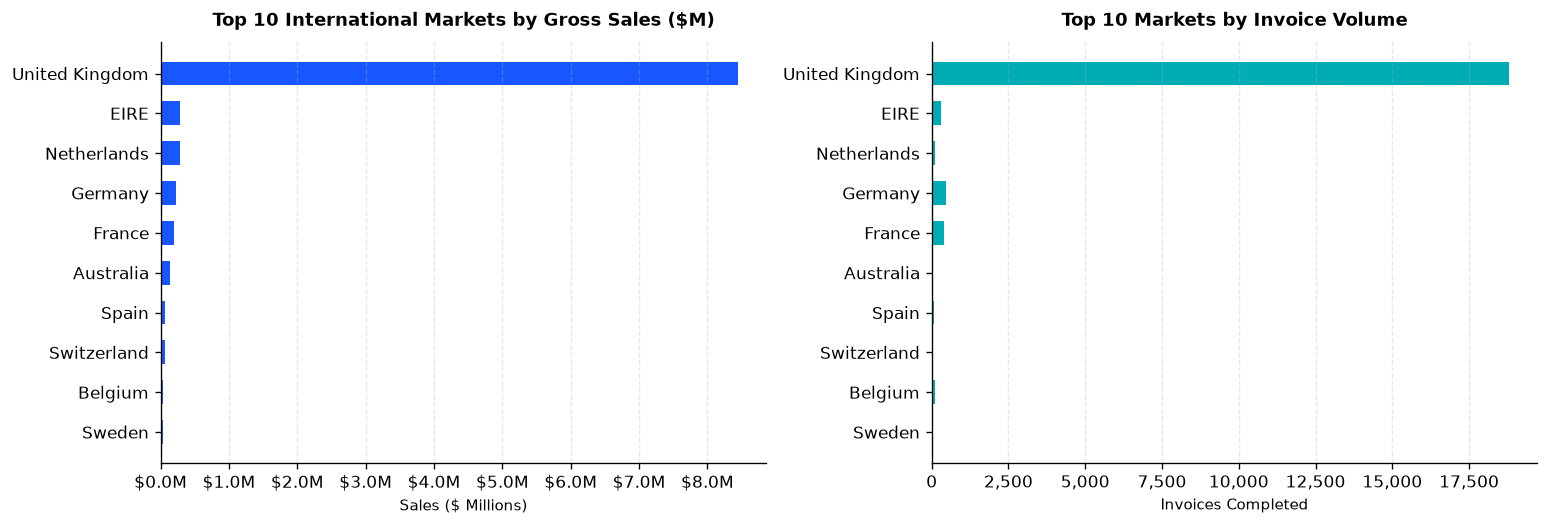

In [4]:
country_perf = valid_df.groupby('Country').agg(
    Revenue=('TotalSales', 'sum'),
    Transactions=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', lambda x: x[x != 'Guest'].nunique())
).sort_values('Revenue', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#FFFFFF')

# Revenue plot
ax1.barh(country_perf.index[::-1], country_perf['Revenue'][::-1] / 1e6, color='#1856FF', height=0.6)
ax1.set_title('Top 10 International Markets by Gross Sales ($M)', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Sales ($ Millions)', fontsize=9)
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:.1f}M'))
ax1.grid(True, linestyle='--', alpha=0.3, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Transaction Count plot
ax2.barh(country_perf.index[::-1], country_perf['Transactions'][::-1], color='#00ADB5', height=0.6)
ax2.set_title('Top 10 Markets by Invoice Volume', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Invoices Completed', fontsize=9)
ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Monthly Cohort Retention Matrix Construction
We group registered buyers by their first order date and measure month-by-month repeat activity across the customer lifecycle.


In [5]:
df_cust_orders = df[(df['CustomerID'] != 'Guest') & (~df['IsCancelled'])].copy()
df_cust_orders['OrderMonth'] = df_cust_orders['InvoiceDate'].dt.to_period('M')
df_cust_orders['CohortMonth'] = df_cust_orders.groupby('CustomerID')['OrderMonth'].transform('min')

df_cust_orders['CohortIndex'] = (
    (df_cust_orders['OrderMonth'].dt.year - df_cust_orders['CohortMonth'].dt.year) * 12 +
    (df_cust_orders['OrderMonth'].dt.month - df_cust_orders['CohortMonth'].dt.month)
)

cohort_counts = df_cust_orders.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_pivot.index = cohort_pivot.index.astype(str)

cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print(f"Total tracked customer cohorts: {len(retention_matrix)}")
retention_matrix.iloc[:6, :6].round(1)


Total tracked customer cohorts: 13
CohortIndex      0     1     2     3     4     5
CohortMonth                                     
2010-12      100.0  36.6  32.3  38.4  36.3  39.8
2011-01      100.0  22.1  26.6  23.0  32.1  28.8
2011-02      100.0  18.7  18.7  28.4  27.1  24.7
2011-03      100.0  15.0  25.2  19.9  22.3  16.8
2011-04      100.0  21.3  20.3  21.0  19.7  22.7
2011-05      100.0  19.0  17.3  17.3  20.8  23.2


## 6. Visualizing Customer Retention Degradation
A Seaborn heatmap reveals initial retention drop-off and long-tail repeat stability.


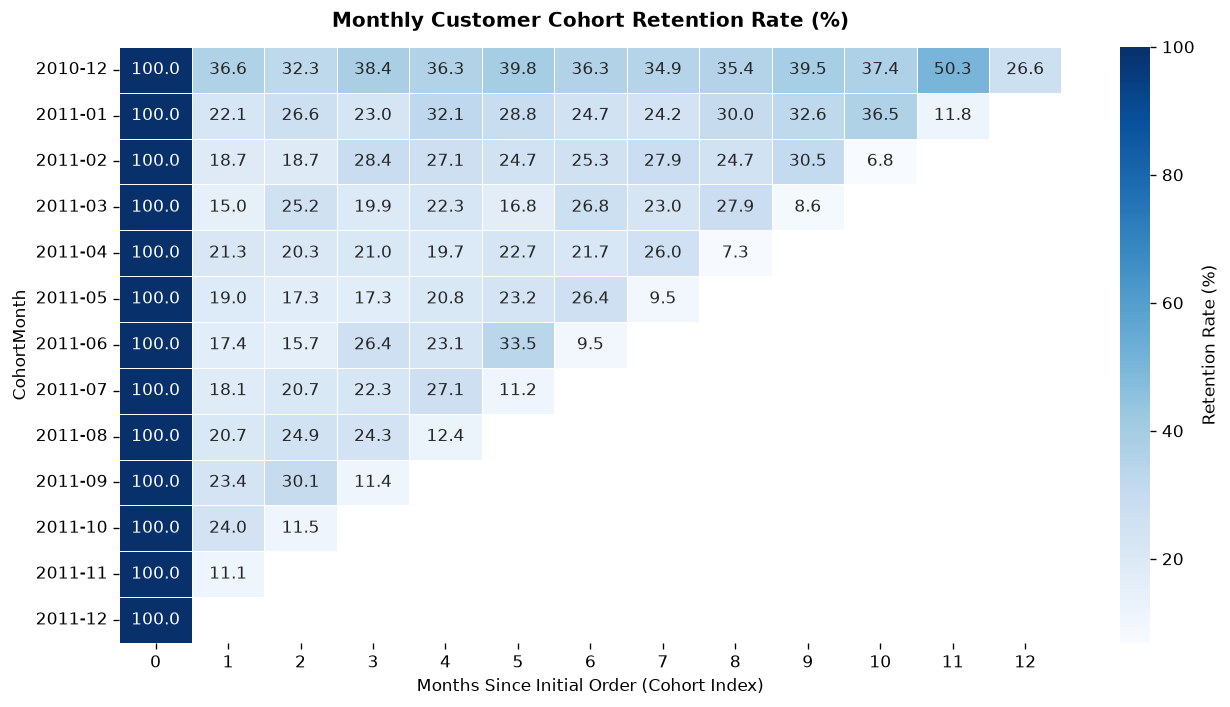

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FFFFFF')

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax
)

ax.set_title('Monthly Customer Cohort Retention Rate (%)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Months Since Initial Order (Cohort Index)', fontsize=10)
ax.set_ylabel('Acquisition Cohort Month', fontsize=10)

plt.tight_layout()
plt.show()


## 7. Customer Recency, Frequency, and Monetary (RFM) Segmentation
We aggregate transactions to calculate customer-level purchase characteristics:
- Recency: Days elapsed between the customer's last order and the final dataset date.
- Frequency: Number of unique invoice orders placed.
- Monetary: Total lifetime revenue spend.


In [7]:
ref_date = df_cust_orders['InvoiceDate'].max()

df_rfm = df_cust_orders.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSales', 'sum')
).reset_index()

# Scoring quintiles
r_labels = [5, 4, 3, 2, 1]
f_labels = [1, 2, 3, 4, 5]
m_labels = [1, 2, 3, 4, 5]

df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], q=5, labels=r_labels, duplicates='drop').astype(int)
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=5, labels=f_labels).astype(int)
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], q=5, labels=m_labels).astype(int)
df_rfm['RFM_Score'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

def map_rfm(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New/Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Hibernating/Lost'

df_rfm['Segment'] = df_rfm.apply(map_rfm, axis=1)
print(f"Total segmented unique customers: {len(df_rfm):,}")
print(df_rfm['Segment'].value_counts())


Total segmented unique customers: 4,339
Segment
Hibernating/Lost    1655
Champions            963
Loyal Customers      758
At Risk              643
New/Promising        320
Name: count, dtype: int64


## 8. Segment Financial Contribution and Distribution
Analyzing customer density versus revenue contribution across each behavioral cohort.


Segment  CustomerCount  AvgMonetary  RevenueShare
1         Champions            963       5900.1          67.6
3   Loyal Customers            758       1555.2          14.0
0           At Risk            643       1136.3           8.7
2  Hibernating/Lost           1655        404.2           8.0
4     New/Promising            320        442.8           1.7


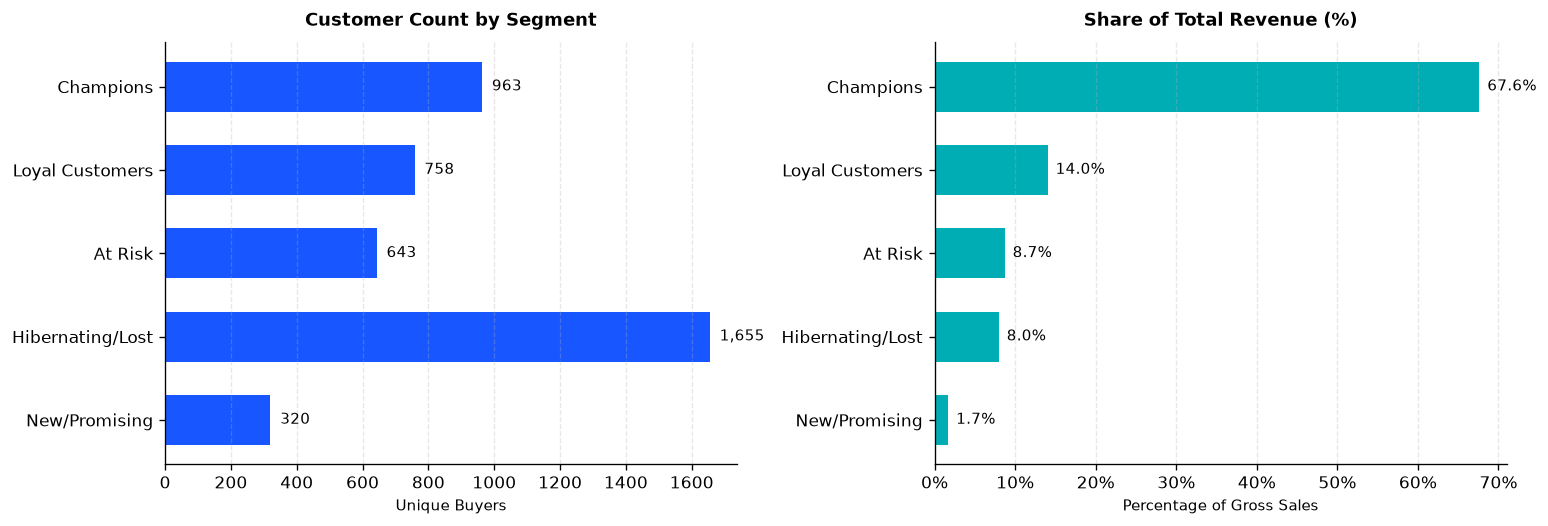

In [8]:
seg_perf = df_rfm.groupby('Segment').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgMonetary=('Monetary', 'mean'),
    TotalMonetary=('Monetary', 'sum')
).reset_index().sort_values('TotalMonetary', ascending=False)

seg_perf['RevenueShare'] = (seg_perf['TotalMonetary'] / seg_perf['TotalMonetary'].sum()) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#FFFFFF')

# Headcount
bars1 = ax1.barh(seg_perf['Segment'][::-1], seg_perf['CustomerCount'][::-1], color='#1856FF', height=0.6)
ax1.set_title('Customer Count by Segment', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Unique Buyers', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.3, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for bar in bars1:
    w = bar.get_width()
    ax1.text(w + 30, bar.get_y() + bar.get_height() / 2, f"{int(w):,}", va='center', fontsize=9)

# Revenue Share
bars2 = ax2.barh(seg_perf['Segment'][::-1], seg_perf['RevenueShare'][::-1], color='#00ADB5', height=0.6)
ax2.set_title('Share of Total Revenue (%)', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Percentage of Gross Sales', fontsize=9)
ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}%'))
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 1, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 9. Executive Conclusions and Pipeline Transition
1. Quality Isolation: Over 24% of transaction lines represent guest checkouts. These must be included in top-line store revenue metrics but excluded from customer cohort retention matrices to prevent skewing user identifiers.
2. Retention Cliff: Retention drops from 100% in month 0 to roughly 20% to 25% by month 1. Onboarding interventions during the first 30 days represent the highest-leverage retention opportunity.
3. Revenue Concentration: Champions and Loyal Customers constitute roughly 40% of the customer base but generate over 75% of cumulative sales revenue.
4. Next Steps: Productionize these aggregation rules into `src/data_prep.py` and `src/data_processing.py` to power the Streamlit presentation layer.
